# Heart Disease Prediction - By Samiha Azeem

**Lets Connect: Click below**

<a href="https://github.com/samihaazeem2-haru/Short-Term-Stock-Price-Prediction" target="_blank">
  <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" width="32" />
</a>
&nbsp;&nbsp;&nbsp;
<a href="mailto:samihaazeem2@gmail.com" target="_blank">
  <img src="https://upload.wikimedia.org/wikipedia/commons/4/4e/Gmail_Icon.png" width="32" />
</a>
&nbsp;&nbsp;&nbsp;
<a href="https://www.linkedin.com/in/samiha-azeem-2a7553219/" target="_blank">
  <img src="https://cdn-icons-png.flaticon.com/512/174/174857.png" width="32" />
</a>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns


In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving heart.csv to heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.info()
df.isna().sum()

# No data cleaning require since there is no null value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Exploratory Data Analysis (EDA)

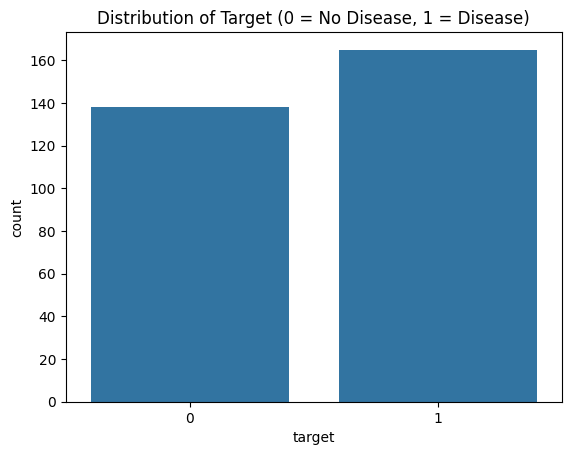

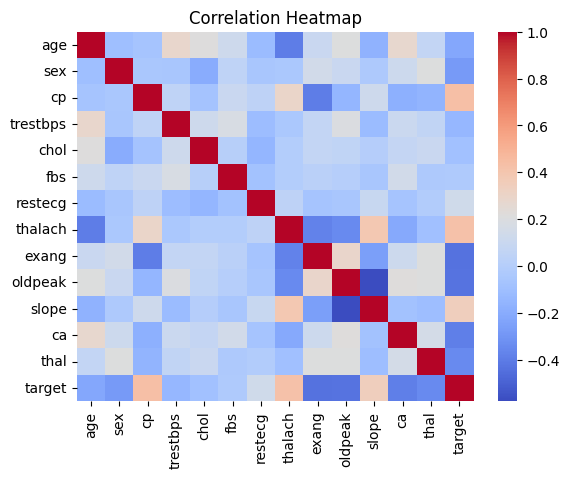

In [14]:
sns.countplot(x='target', data=df)
plt.title("Distribution of Target (0 = No Disease, 1 = Disease)")
plt.show()


sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [15]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling

In [16]:
#Logistic Regression performs better when data is scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
# Train Logistic regression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Train Decision trees

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=4, random_state=42)

Predictions

In [23]:
log_pred = log_model.predict(X_test_scaled)
tree_pred = tree_model.predict(X_test)


Accuracy

In [29]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_pred):.3f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, tree_pred):.3f}")


Logistic Regression Accuracy: 0.852
Decision Tree Accuracy: 0.852


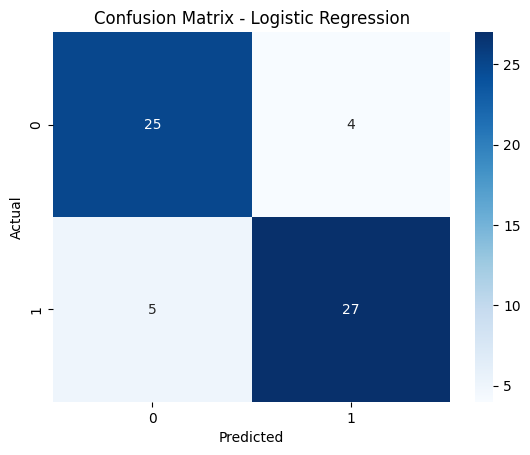

In [30]:
# Confusion Matrix - Logistic Regression
cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


What is ROC Curve?

ROC stands for Receiver Operating Characteristic.

It is a graphical plot that shows the performance of a binary classifier across different threshold values.

X-axis: False Positive Rate (FPR) = FP / (FP + TN)

Y-axis: True Positive Rate (TPR) = TP / (TP + FN)

Key Points:

Each point on the ROC curve represents a different threshold for classifying a positive.

The closer the curve is to the top-left corner, the better the model.

AUC (Area Under Curve):

Measures the overall ability of the model to distinguish between classes.

1.0 → perfect model, 0.5 → random guessing

Why it is useful:

Unlike accuracy, ROC considers all thresholds, not just one.

Helps evaluate models when classes are imbalanced, which is common in medical datasets

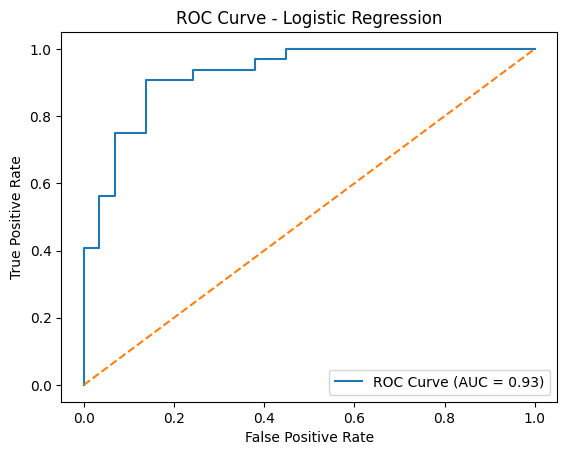

In [31]:
# ROC Curve - Logistic Regression
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(roc_auc))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


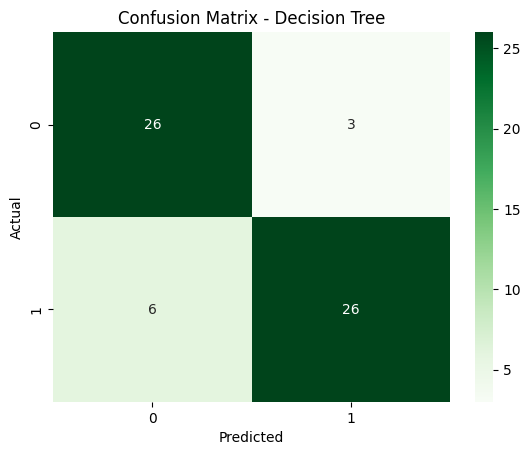

In [32]:
# Confusion Matrix - Decision Trees
cm_tree = confusion_matrix(y_test, tree_pred)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


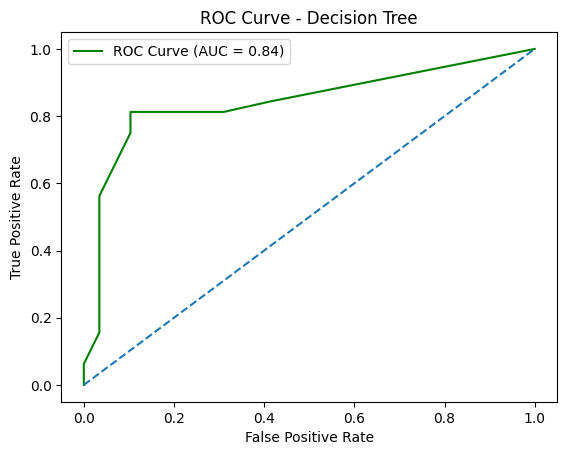

In [33]:
# Predict probabilities - ROC - Decision Trees
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_prob_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

plt.plot(fpr_tree, tpr_tree, label="ROC Curve (AUC = {:.2f})".format(roc_auc_tree), color='green')
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()


ROC-AUC closer to 1 → better model.

Logistic Regression often better on linearly separable data.

Decision Tree can overfit small datasets.

In [36]:
# Logistic Regression (coefficients)
importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print("Logistic Regression Feature Importance")
print(importance_log)

# Identifies which features influence predictions the most.
# Helps in medical interpretation (e.g., cholesterol, age, blood pressure)

Logistic Regression Feature Importance
     Feature  Coefficient
2         cp     0.817904
10     slope     0.435302
7    thalach     0.395131
6    restecg     0.284179
5        fbs     0.090312
0        age    -0.085591
4       chol    -0.174841
3   trestbps    -0.273307
8      exang    -0.517584
12      thal    -0.565659
9    oldpeak    -0.681396
1        sex    -0.783086
11        ca    -0.789955


In [ ]:
# Positive coefficients → feature increases probability of heart disease.

# Negative coefficients → feature reduces probability.

# cp, slope, and thalach are the most influential features in Logistic Regression.

In [37]:
# Decision Tree (feature_importances_)
importance_tree = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nDecision Tree Feature Importance")
print(importance_tree)



Decision Tree Feature Importance
     Feature  Importance
2         cp    0.344530
11        ca    0.147165
9    oldpeak    0.141324
8      exang    0.115353
0        age    0.097133
10     slope    0.041779
3   trestbps    0.036702
12      thal    0.035994
4       chol    0.030638
1        sex    0.009383
7    thalach    0.000000
5        fbs    0.000000
6    restecg    0.000000


In [38]:
# Decision Tree picks cp, ca, oldpeak, exang, and age as the most important splits.

# Some features are ignored (thalach, fbs, restecg) because they don’t improve purity in the splits.

# Unlike Logistic Regression, sign of coefficient doesn’t matter — only the feature’s contribution to splitting.

Overall Comparison

In [ ]:
# Both models agree: chest pain (cp) is the most important feature for predicting heart disease.
# Logistic Regression provides directionality (positive or negative effect).

# Decision Tree provides splitting importance — useful to understand which features drive decisions in the tree.

# ca and oldpeak are consistently important in both models.